# Problema 2

### Clasificare binara -> regresie logistica

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
import math
import warnings; warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt
import os
import numpy as np


# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
y = y['Diagnosis']

inputs = [[x,y] for x,y in zip(X['radius1'],X['texture2'])]

# normalisation function
def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData



### Impartirea datelor pe train & test + standardizarea acestora

In [14]:
from sklearn.decomposition import PCA

# making sure that the "random" numbers are always going to be the same ones (in order to get the same results every time)
np.random.seed(5)

# building an index vector & selecting 80% of it for training, and the rest 20% for testing the algorithm
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]


trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [y[i] for i in trainSample]

testInputs = [inputs[i] for i in testSample]
testOutputs = [y[i] for i in testSample]

trainInputs, testInputs = normalisation(trainInputs, testInputs)

## Train + Predictii -> CU TOOL

In [15]:
regressor = LogisticRegression()

regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_[0], regressor.coef_[0][0], regressor.coef_[0][1]
print('the learnt model f(x) = ', w0, ' + ', w1, ' * x1 + ',w2 , ' * x2')

the learnt model f(x) =  -0.7665136809929488  +  3.7556416514354063  * x1 +  0.3776378966791838  * x2


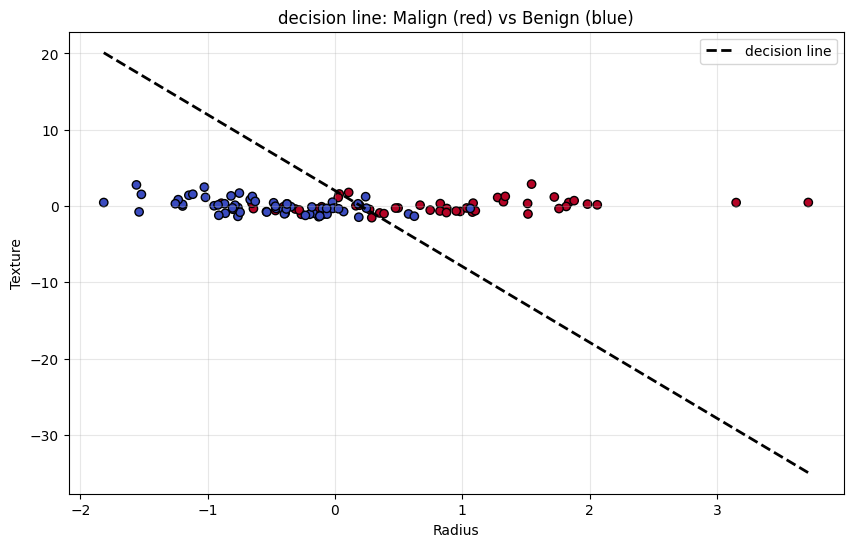

In [16]:
computedOutputs = regressor.predict(testInputs)


x_coords = [x[0] for x in testInputs] # datele pentru raza
y_coords = [x[1] for x in testInputs] # datele pentru textura


plot_colors = [1 if y == 'M' else 0 for y in testOutputs]

plt.figure(figsize=(10, 6))
plt.scatter(x_coords, y_coords, c=plot_colors, cmap='coolwarm', edgecolors='k')

# linia de decizie
x_vals = np.array([min(x_coords), max(x_coords)])

# reiese din formula f(x) = w0 + w1 * x1 + w2 * x2 (in cazul de fata, y fiind x2)
# => x2 = -( w0 + w1 * x1) / w2
y_vals = -(w1 * x_vals + w0) / w2

plt.plot(x_vals, y_vals, '--', color='black', linewidth=2, label='decision line', zorder=4)

plt.xlabel('Radius')
plt.ylabel('Texture')
plt.title('decision line: Malign (red) vs Benign (blue)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Train + Predictii -> COD PROPRIU

In [17]:
from MyLogisticRegression import MyLogisticRegression

regressorP = MyLogisticRegression()
binarTrainOutputs = [1 if y == 'M' else 0 for y in trainOutputs]

regressorP.fit(trainInputs, binarTrainOutputs)
w0p, w1p, w2p = regressorP.intercept_, regressorP.coef_[0], regressorP.coef_[1]
print('the learnt model f(x) = ', w0p, ' + ', w1p, ' * x1 + ',w2p , ' * x2')

the learnt model f(x) =  -0.5955032073382964  +  2.0435114175238995  * x1 +  0.16687048877226673  * x2


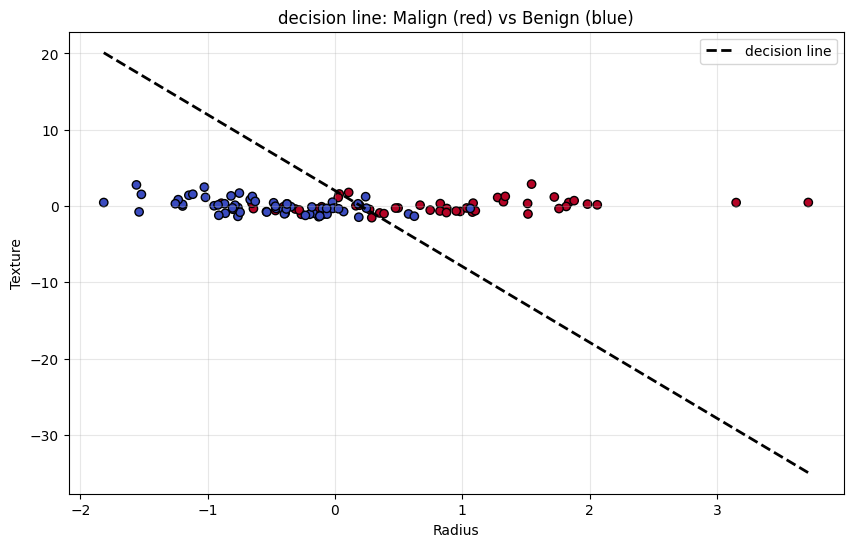

In [18]:
computedOutputsP = regressorP.predict(testInputs)


x_coords = [x[0] for x in testInputs] # datele pentru raza
y_coords = [x[1] for x in testInputs] # datele pentru textura


plot_colors = [1 if y == 'M' else 0 for y in testOutputs]

plt.figure(figsize=(10, 6))
plt.scatter(x_coords, y_coords, c=plot_colors, cmap='coolwarm', edgecolors='k')

# linia de decizie
x_vals = np.array([min(x_coords), max(x_coords)])

# reiese din formula f(x) = w0 + w1 * x1 + w2 * x2 (in cazul de fata, y fiind x2)
# => x2 = -( w0 + w1 * x1) / w2
y_vals = -(w1 * x_vals + w0) / w2

plt.plot(x_vals, y_vals, '--', color='black', linewidth=2, label='decision line', zorder=4)


plt.xlabel('Radius')
plt.ylabel('Texture')
plt.title('decision line: Malign (red) vs Benign (blue)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Metrici de performanta

In [19]:
TP = 0
FP = 0
TN = 0
FN = 0


# TOOL MODEL
for i in range(len(testOutputs)):
    if testOutputs[i] == 'M' and computedOutputs[i] == 'M':
        TP += 1
    elif testOutputs[i] != 'M' and computedOutputs[i] == 'M':
        FP += 1
    elif testOutputs[i] != 'M' and computedOutputs[i] != 'M':
        TN += 1
    else:
        FN += 1

accuracy = (TP + TN) / (TP + TN + FP + FP)
precision = TP / (TP + FP)
recall = TP/ (TP + FN)

print('TOOL MODEL')
print('the model accuracy is: ', accuracy)
print('the model precision is: ', precision)
print('the model recall is: ', recall)


# MY MODEL
for i in range(len(testOutputs)):
    if testOutputs[i] == 'M' and computedOutputsP[i] == 1:
        TP += 1
    elif testOutputs[i] != 'M' and computedOutputsP[i] == 1:
        FP += 1
    elif testOutputs[i] != 'M' and computedOutputsP[i] != 1:
        TN += 1
    else:
        FN += 1

accuracy = (TP + TN) / (TP + TN + FP + FP)
precision = TP / (TP + FP)
recall = TP/ (TP + FN)

print('\nMY MODEL')
print('the model accuracy is: ', accuracy)
print('the model precision is: ', precision)
print('the model recall is: ', recall)

TOOL MODEL
the model accuracy is:  0.883495145631068
the model precision is:  0.8461538461538461
the model recall is:  0.66

MY MODEL
the model accuracy is:  0.900497512437811
the model precision is:  0.863013698630137
the model recall is:  0.63


In [20]:
# predictie exemplu

leziune_noua = [[18,10]]
rez = regressor.predict(leziune_noua)
if rez[0] == 'M':
    rez = 'Malign'
else:
    rez = 'Benign'
print("Modelul antrenat cu tool spune ca leziunea este: " + rez)

rez = regressorP.predict(leziune_noua)
if rez[0] == 1:
    rez = 'Malign'
else:
    rez = 'Benign'
print("Modelul antrenat utilizand cod propriu spune ca leziunea este: " + rez)

Modelul antrenat cu tool spune ca leziunea este: Malign
Modelul antrenat utilizand cod propriu spune ca leziunea este: Malign


### Modificarea pragului de decizie

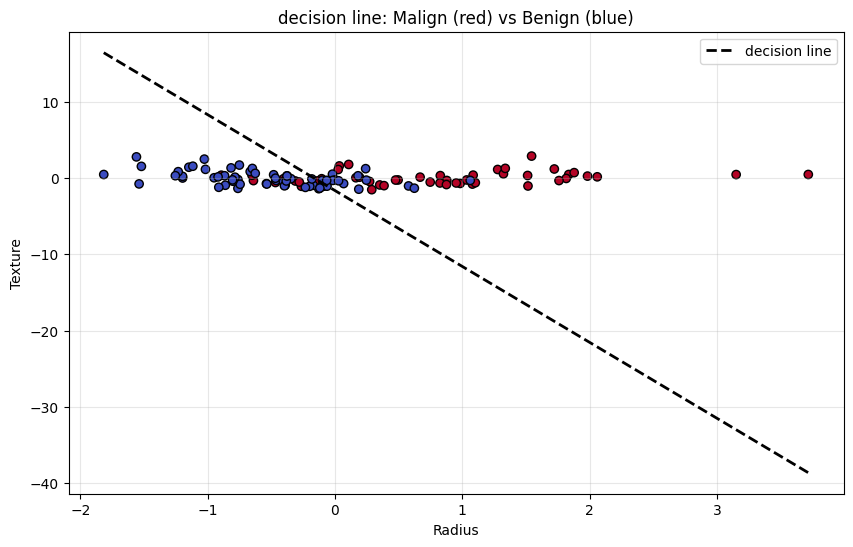

In [21]:
prob = regressor.predict_proba(testInputs)

new_threshold = 0.2
prob_malign = prob[:, 1] # it takes all the malign probabilities from data

finalOutput = [1 if p > new_threshold else 0 for p in prob_malign]

# visualising the result

x_coords = [x[0] for x in testInputs] # datele pentru raza
y_coords = [x[1] for x in testInputs] # datele pentru textura


plot_colors = [1 if y == 'M' else 0 for y in testOutputs]

plt.figure(figsize=(10, 6))
plt.scatter(x_coords, y_coords, c=plot_colors, cmap='coolwarm', edgecolors='k')

# linia de decizie
x_vals = np.array([min(x_coords), max(x_coords)])

# formula clasica este: z = ln(p/(1-p)) (dupa aplicarea sigmoidului)
# z = w0 + w1*x1 + w2*x2
# pentru a-l scoate pe x2: (-w0 - w1*x1 + ln(p/(1-p))/w2
y_vals = (-w1 * x_vals - w0 + np.log(new_threshold/(1 - new_threshold))) / w2

plt.plot(x_vals, y_vals, '--', color='black', linewidth=2, label='decision line', zorder=4)


plt.xlabel('Radius')
plt.ylabel('Texture')
plt.title('decision line: Malign (red) vs Benign (blue)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Verificarea performantei in functie de pragul de decizie ales

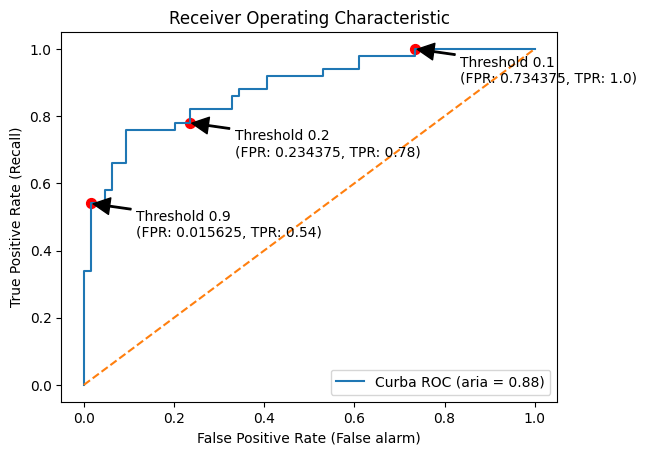

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# selecting only the malign probabilities
probs = regressor.predict_proba(testInputs)[:, 1]

# obtaining the curve
binaryTestOutputs = [1 if y == 'M' else 0 for y in testOutputs]
fpr, tpr, thresholds = roc_curve(binaryTestOutputs, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Curba ROC (aria = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

# finding the point that maximizes the true positives
idx_2 = np.argmin(np.abs(thresholds - 0.2))

# finding the point that minimizes the false positives
idx_9 = np.argmin(np.abs(thresholds - 0.9))

idx_1 = np.argmin(np.abs(thresholds - 0.01))

# for showing the points on the diagram
plt.scatter(fpr[idx_2], tpr[idx_2], color='red', s=50)
plt.annotate(f'Threshold 0.2\n(FPR: {fpr[idx_2]}, TPR: {tpr[idx_2]})',
             xy=(fpr[idx_2], tpr[idx_2]),
             # the position for the text (moving it a bit to the right and lower, in order to not be on top of the point)
             xytext=(fpr[idx_2]+0.1, tpr[idx_2]-0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.scatter(fpr[idx_9], tpr[idx_9], color='red', s=50)
plt.annotate(f'Threshold 0.9\n(FPR: {fpr[idx_9]}, TPR: {tpr[idx_9]})',
             xy=(fpr[idx_9], tpr[idx_9]),
             # the position for the text (moving it a bit to the right and lower, in order to not be on top of the point)
             xytext=(fpr[idx_9]+0.1, tpr[idx_9]-0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.scatter(fpr[idx_1], tpr[idx_1], color='red', s=50)
plt.annotate(f'Threshold 0.1\n(FPR: {fpr[idx_1]}, TPR: {tpr[idx_1]})',
             xy=(fpr[idx_1], tpr[idx_1]),
             # the position for the text (moving it a bit to the right and lower, in order to not be on top of the point)
             xytext=(fpr[idx_1]+0.1, tpr[idx_1]-0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.xlabel('False Positive Rate (False alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right ")
plt.show()



### Cross Validation + predictie

In [23]:
# creating k equal parts of data

k = 5

np.random.shuffle(trainSample)
# only spliting 80% of the data, so we can keep the 20% for the final testing
parts = np.array_split(trainSample, k)

# final testing data
finalTestInputs = [inputs[i] for i in testSample]
finalTestOutputs = [y[i] for i in testSample]

dataPartsInputs = []
dataPartsOutputs = []
for part in parts:
    data = [inputs[part[i]] for i in range(len(part))]
    dataPartsInputs.append(data)

    data = [y[part[i]] for i in range(len(part))]
    dataPartsOutputs.append(data)

accuracy = []

# training the model k times
clasificatorCross = LogisticRegression()

for run in range(k):
    # choosing the test part
    testInput = dataPartsInputs[run]
    testOutputs = dataPartsOutputs[run]

    trainInput = np.concatenate([dataPartsInputs[i] for i in range(len(dataPartsInputs))  if i != run])
    trainOutputs = np.concatenate([dataPartsOutputs[i] for i in range(len(dataPartsOutputs)) if i != run])

    # normalisation
    scaler = StandardScaler()
    scaler.fit(trainInput)  #  fit only on training data
    trainInput = scaler.transform(trainInput) # apply same transformation to train data
    testInput = scaler.transform(testInput)

    # training the model
    clasificatorCross.fit(trainInput, trainOutputs)

    accuracyRun = clasificatorCross.score(testInput, testOutputs)
    accuracy.append(accuracyRun)
    print(f"Step {run + 1}: accuracy = {accuracyRun}")

print("Overall Accuracy = ", np.mean(accuracy))

leziune_noua = [[18,10]]
rez = clasificatorCross.predict(leziune_noua)

if rez[0] == 'M':
    rez = 'Malign'
else:
    rez = 'Benign'
print("Modelul antrenat cu tool spune ca leziunea este: " + rez)



Step 1: accuracy = 0.9120879120879121
Step 2: accuracy = 0.8351648351648352
Step 3: accuracy = 0.9120879120879121
Step 4: accuracy = 0.945054945054945
Step 5: accuracy = 0.9230769230769231
Overall Accuracy =  0.9054945054945055
Modelul antrenat cu tool spune ca leziunea este: Malign


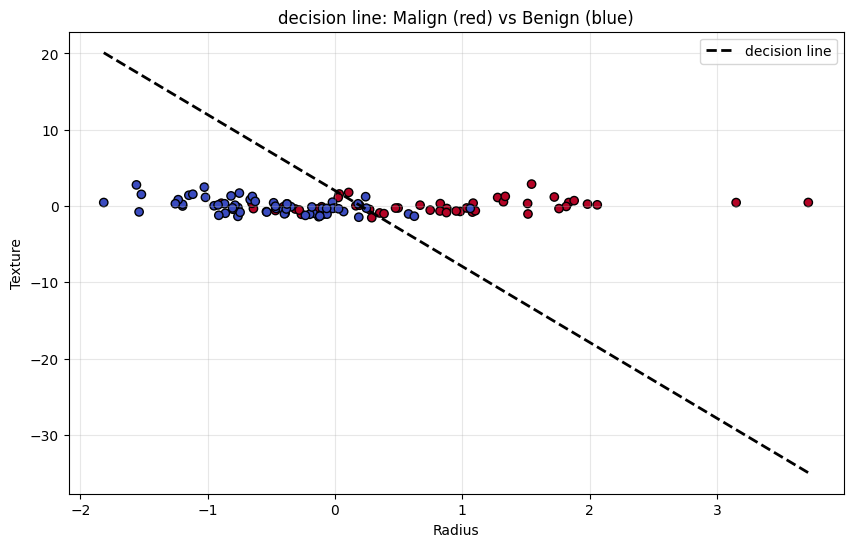

In [24]:
# prediction for the last data test

# overall normalisation
trainInputs = np.concatenate([dataPartsInputs[i] for i in range(len(dataPartsInputs))])
scaler = StandardScaler()
scaler.fit(trainInputs)  #  fit only on training data
trainInputs = scaler.transform(trainInputs) # apply same transformation to train data
finalTestInputs = scaler.transform(finalTestInputs)

computedOutputsCross = clasificatorCross.predict(finalTestInputs)

x_coords = [x[0] for x in finalTestInputs] # datele pentru raza
y_coords = [x[1] for x in finalTestInputs] # datele pentru textura


plot_colors = [1 if y == 'M' else 0 for y in finalTestOutputs]

plt.figure(figsize=(10, 6))
plt.scatter(x_coords, y_coords, c=plot_colors, cmap='coolwarm', edgecolors='k')

# linia de decizie
x_vals = np.array([min(x_coords), max(x_coords)])

# reiese din formula f(x) = w0 + w1 * x1 + w2 * x2 (in cazul de fata, y fiind x2)
# => x2 = -( w0 + w1 * x1) / w2
y_vals = -(w1 * x_vals + w0) / w2

plt.plot(x_vals, y_vals, '--', color='black', linewidth=2, label='decision line', zorder=4)


plt.xlabel('Radius')
plt.ylabel('Texture')
plt.title('decision line: Malign (red) vs Benign (blue)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()